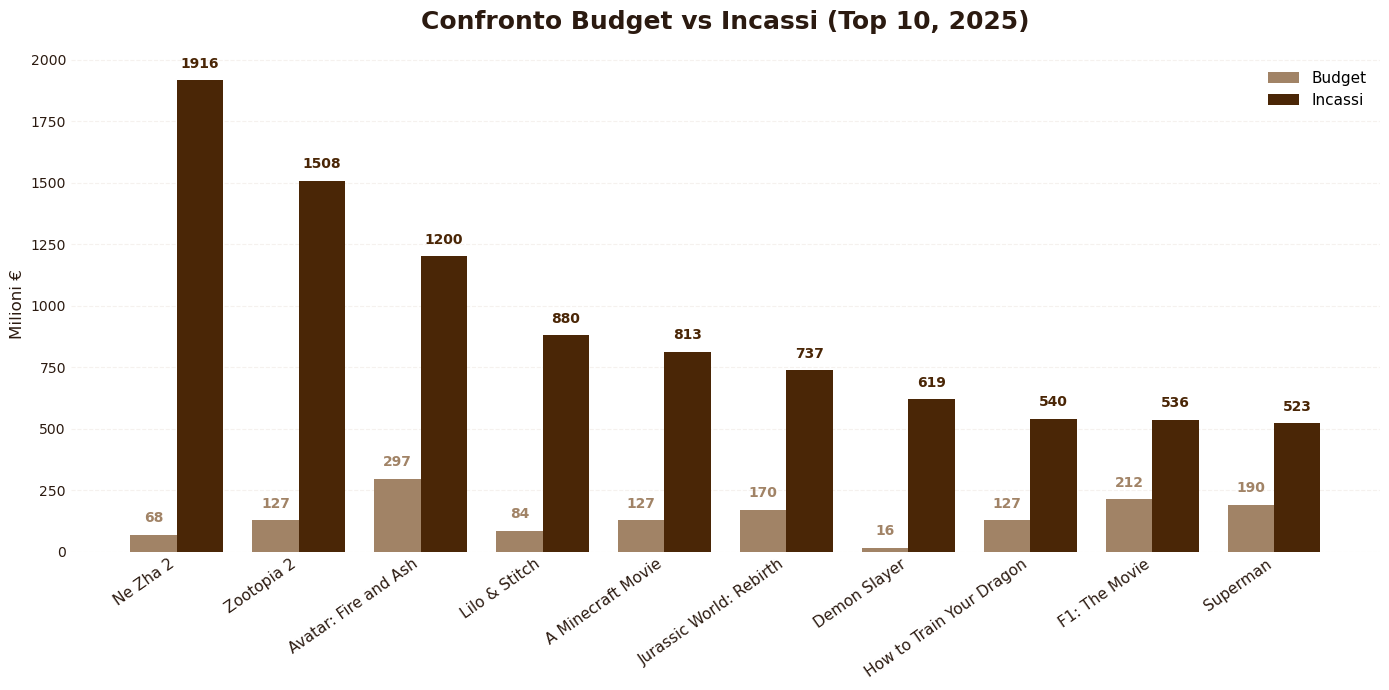

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

def leggi_csv(nome_file):
    df = pd.read_csv(nome_file)
    df.columns = df.columns.str.strip()
    df = df.loc[:, [c for c in df.columns if not str(c).lower().startswith("unnamed")]]
    return df

def norm_film(x):
    if pd.isna(x):
        return ""
    return str(x).strip().lower()

def parse_budget_eur(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in ["", "-", "nan", "none"]:
        return np.nan
    s = s.replace("€", "").replace("$", "")
    m = re.search(r"(\d+(?:[.,]\d+)?)", s)
    if not m:
        return np.nan
    num = float(m.group(1).replace(",", "."))
    if "miliard" in s:
        return num * 1e9
    if "milion" in s:
        return num * 1e6
    return num

def parse_money(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.lower() in ["", "-", "nan", "none"]:
        return np.nan
    s = re.sub(r"[€$]", "", s)
    s = s.replace(" ", "")
    s = re.sub(r"[^0-9,\.]", "", s)
    if s == "":
        return np.nan
    if "," in s and "." in s:
        s = s.replace(".", "").replace(",", ".")
    else:
        if s.count(".") >= 2 and "," not in s:
            s = s.replace(".", "")
        elif s.count(",") >= 2 and "." not in s:
            s = s.replace(",", "")
        else:
            if "," in s and "." not in s:
                s = s.replace(".", "").replace(",", ".")
            elif "." in s and "," not in s:
                parts = s.split(".")
                if len(parts[-1]) == 3 and all(len(p) <= 3 for p in parts[:-1]):
                    s = "".join(parts)
    try:
        return float(s)
    except:
        return np.nan

budget = leggi_csv("Budget.csv")
incassi = leggi_csv("IncassiTot.csv")

budget = budget.rename(columns={"Nome del film": "Film"})
incassi = incassi.rename(columns={"Nome del film": "Film"})

budget["Film_key"] = budget["Film"].apply(norm_film)
incassi["Film_key"] = incassi["Film"].apply(norm_film)

budget["Budget_EUR"] = budget["Budget (in euro)"].apply(parse_budget_eur)
incassi["Incassi_EUR"] = incassi["Incassi (in euro)"].apply(parse_money)

df = budget[["Film", "Film_key", "Budget_EUR"]].merge(
    incassi[["Film_key", "Incassi_EUR"]],
    on="Film_key",
    how="inner"
)

df = df.dropna(subset=["Budget_EUR", "Incassi_EUR"]).copy()
df["Budget_M"] = df["Budget_EUR"] / 1e6
df["Incassi_M"] = df["Incassi_EUR"] / 1e6

df = df.sort_values("Incassi_M", ascending=False).reset_index(drop=True)

if df.shape[0] == 0:
    raise ValueError("Nessun dato valido: controlla Budget.csv e IncassiTot.csv.")


color_budget = "#A18366"  
color_incassi = "#4a2606" 

x = np.arange(len(df))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 7))

fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.bar(x - w/2, df["Budget_M"], width=w, color=color_budget, edgecolor="none", label="Budget")
ax.bar(x + w/2, df["Incassi_M"], width=w, color=color_incassi, edgecolor="none", label="Incassi")

ax.set_title("Confronto Budget vs Incassi (Top 10, 2025)", fontsize=18, pad=20, weight="bold", color="#2b1a10")
ax.set_ylabel("Milioni €", fontsize=12, color="#2b1a10")

ax.set_xticks(x)
ax.set_xticklabels(df["Film"].tolist(), rotation=35, ha="right", fontsize=11, color="#2b1a10")

ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.25, color="#d9c8bd")
ax.xaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0, colors="#2b1a10")

ymax = max(df["Budget_M"].max(), df["Incassi_M"].max())
for i in range(len(df)):
    ax.text(x[i] - w/2, df.loc[i, "Budget_M"] + ymax*0.02, f"{df.loc[i,'Budget_M']:.0f}",
            ha="center", va="bottom", fontsize=10, color=color_budget, fontweight="bold")
    ax.text(x[i] + w/2, df.loc[i, "Incassi_M"] + ymax*0.02, f"{df.loc[i,'Incassi_M']:.0f}",
            ha="center", va="bottom", fontsize=10, color=color_incassi, fontweight="bold")

ax.legend(frameon=False, fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()